# Visual Model Analysis: Your RQwen3 Transformer

This notebook gives you **visual tools** to understand your from-scratch Qwen3-style model.

Every visualization works now (with random weights) and will become *way more interesting*
once you train the model — run the same cells again and compare.

## What You'll See
1. **Where the parameters live** — which parts of your model are biggest?
2. **What random weights look like** — the starting point before any learning
3. **What untrained attention looks like** — spoiler: it's basically random
4. **How signals flow through the network** — does information survive 28 layers?
5. **Comparison tools** — save snapshots now, compare after training later

In [2]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import pandas as pd
from collections import OrderedDict

from src import CoreConfig, RQwen3, ModelTokenizer
from src.utils import get_device, format_param_count

# Plot style
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
COLORS = sns.color_palette('Set2', 8)

device = get_device()
print(f'Device: {device}')

Device: mps


In [3]:
config = CoreConfig()
model = RQwen3(config).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model: RQwen3 (untrained)')
print(f'Total parameters: {total_params:,} ({format_param_count(total_params)})')
print(f'Layers: {config.n_layer}')
print(f'Hidden size (d_model): {config.d_model}')
print(f'Attention heads: {config.num_heads} Q, {config.num_kv_heads} KV (grouped query)')
print(f'FFN intermediate size: {config.intermediate_size}')
print(f'Vocab size: {config.vocab_size:,}')

Model: RQwen3 (untrained)
Total parameters: 507,940,352 (508M)
Layers: 28
Hidden size (d_model): 512
Attention heads: 16 Q, 8 KV (grouped query)
FFN intermediate size: 6144
Vocab size: 151,936


---
## Part 1: Where Do the Parameters Live?

A transformer has several major components. Let's see how many parameters each one uses.

**Key insight**: Attention gets all the hype, but it's not where most of the parameters are.

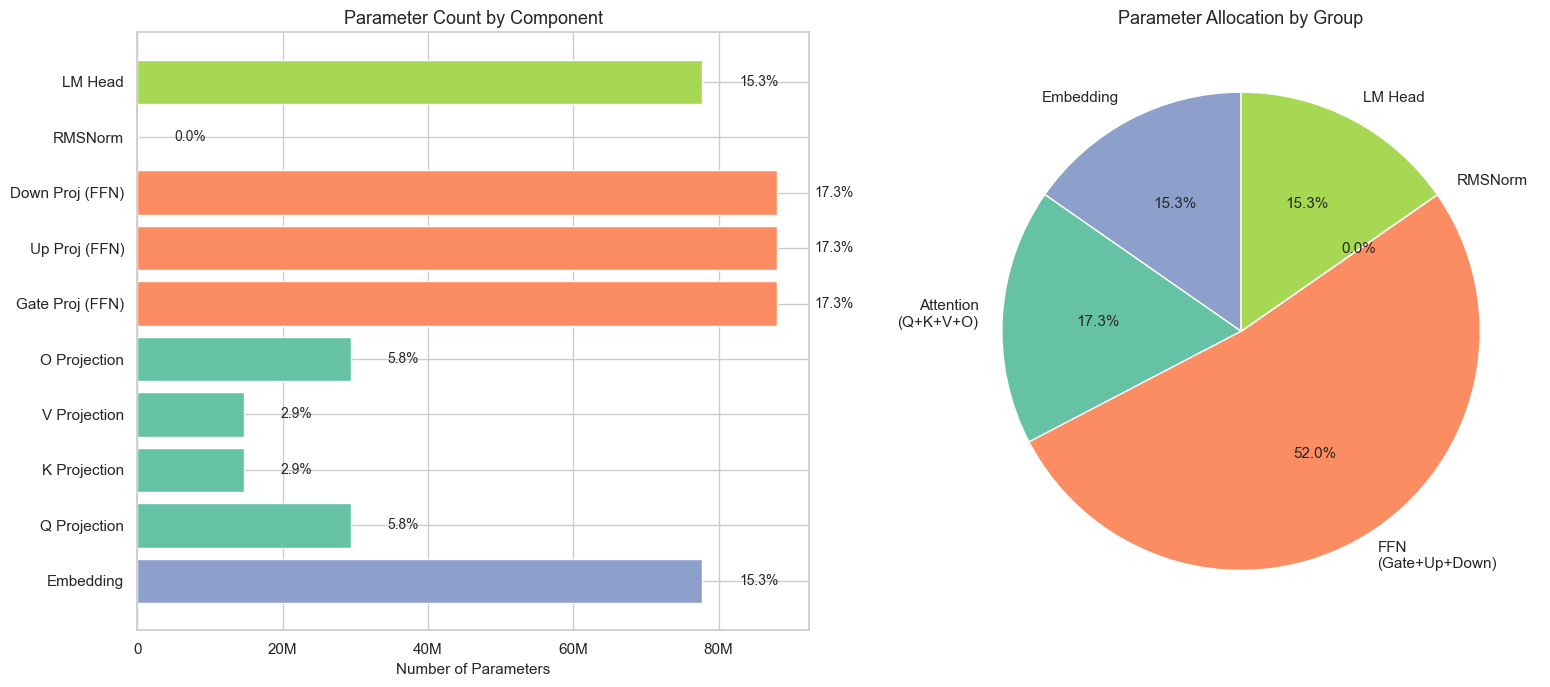


Component                  Params        %
------------------------------------------
Embedding              77,791,232    15.3%
Q Projection           29,360,128     5.8%
K Projection           14,680,064     2.9%
V Projection           14,680,064     2.9%
O Projection           29,360,128     5.8%
Gate Proj (FFN)        88,080,384    17.3%
Up Proj (FFN)          88,080,384    17.3%
Down Proj (FFN)        88,080,384    17.3%
RMSNorm                    36,352     0.0%
LM Head                77,791,232    15.3%
------------------------------------------
TOTAL                 507,940,352   100.0%


In [4]:
def get_detailed_breakdown(model):
    categories = OrderedDict({
        'Embedding': 0,
        'Q Projection': 0,
        'K Projection': 0,
        'V Projection': 0,
        'O Projection': 0,
        'Gate Proj (FFN)': 0,
        'Up Proj (FFN)': 0,
        'Down Proj (FFN)': 0,
        'RMSNorm': 0,
        'LM Head': 0,
    })

    for name, param in model.named_parameters():
        n = param.numel()
        if 'embedding_layer' in name:
            categories['Embedding'] += n
        elif 'q_proj' in name:
            categories['Q Projection'] += n
        elif 'k_proj' in name:
            categories['K Projection'] += n
        elif 'v_proj' in name:
            categories['V Projection'] += n
        elif 'o_proj' in name:
            categories['O Projection'] += n
        elif 'gate_proj' in name:
            categories['Gate Proj (FFN)'] += n
        elif 'up_proj' in name:
            categories['Up Proj (FFN)'] += n
        elif 'down_proj' in name:
            categories['Down Proj (FFN)'] += n
        elif 'lm_head' in name and 'norm' not in name:
            categories['LM Head'] += n
        else:
            categories['RMSNorm'] += n

    return categories


breakdown = get_detailed_breakdown(model)
total = sum(breakdown.values())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Bar chart ---
names = list(breakdown.keys())
values = list(breakdown.values())
percentages = [v / total * 100 for v in values]

group_colors = {
    'Embedding': COLORS[2],
    'Q Projection': COLORS[0], 'K Projection': COLORS[0],
    'V Projection': COLORS[0], 'O Projection': COLORS[0],
    'Gate Proj (FFN)': COLORS[1], 'Up Proj (FFN)': COLORS[1],
    'Down Proj (FFN)': COLORS[1],
    'RMSNorm': COLORS[3],
    'LM Head': COLORS[4],
}
bar_colors = [group_colors[n] for n in names]

bars = ax1.barh(names, values, color=bar_colors)
ax1.set_xlabel('Number of Parameters')
ax1.set_title('Parameter Count by Component')
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format_param_count(int(x))))

for bar, pct in zip(bars, percentages):
    width = bar.get_width()
    ax1.text(width + total * 0.01, bar.get_y() + bar.get_height() / 2,
             f'{pct:.1f}%', va='center', fontsize=10)

# --- Pie chart (grouped) ---
grouped = OrderedDict({
    'Embedding': breakdown['Embedding'],
    'Attention\n(Q+K+V+O)': sum(breakdown[k] for k in ['Q Projection', 'K Projection', 'V Projection', 'O Projection']),
    'FFN\n(Gate+Up+Down)': sum(breakdown[k] for k in ['Gate Proj (FFN)', 'Up Proj (FFN)', 'Down Proj (FFN)']),
    'RMSNorm': breakdown['RMSNorm'],
    'LM Head': breakdown['LM Head'],
})
pie_colors = [COLORS[2], COLORS[0], COLORS[1], COLORS[3], COLORS[4]]
ax2.pie(grouped.values(), labels=grouped.keys(), autopct='%1.1f%%',
        colors=pie_colors, startangle=90, textprops={'fontsize': 11})
ax2.set_title('Parameter Allocation by Group')

plt.tight_layout()
plt.show()

# Print table
print(f"\n{'Component':<20} {'Params':>12} {'%':>8}")
print('-' * 42)
for name, count in breakdown.items():
    print(f'{name:<20} {count:>12,} {count/total*100:>7.1f}%')
print('-' * 42)
print(f"{'TOTAL':<20} {total:>12,} {'100.0%':>8}")

---
## Part 2: What Do Random Weights Look Like?

Your model hasn't been trained yet — all weights are at their **initialization values**.

PyTorch's default initialization for `nn.Linear` is **Kaiming uniform** (scaled by layer size).
For `nn.Embedding`, it's **standard normal** (mean=0, std=1).

> **Why this matters**: After training, weight distributions change dramatically.
> Comparing "before" and "after" reveals what the model *learned*.
> Weights that stay near zero weren't useful; weights that grew large became important.

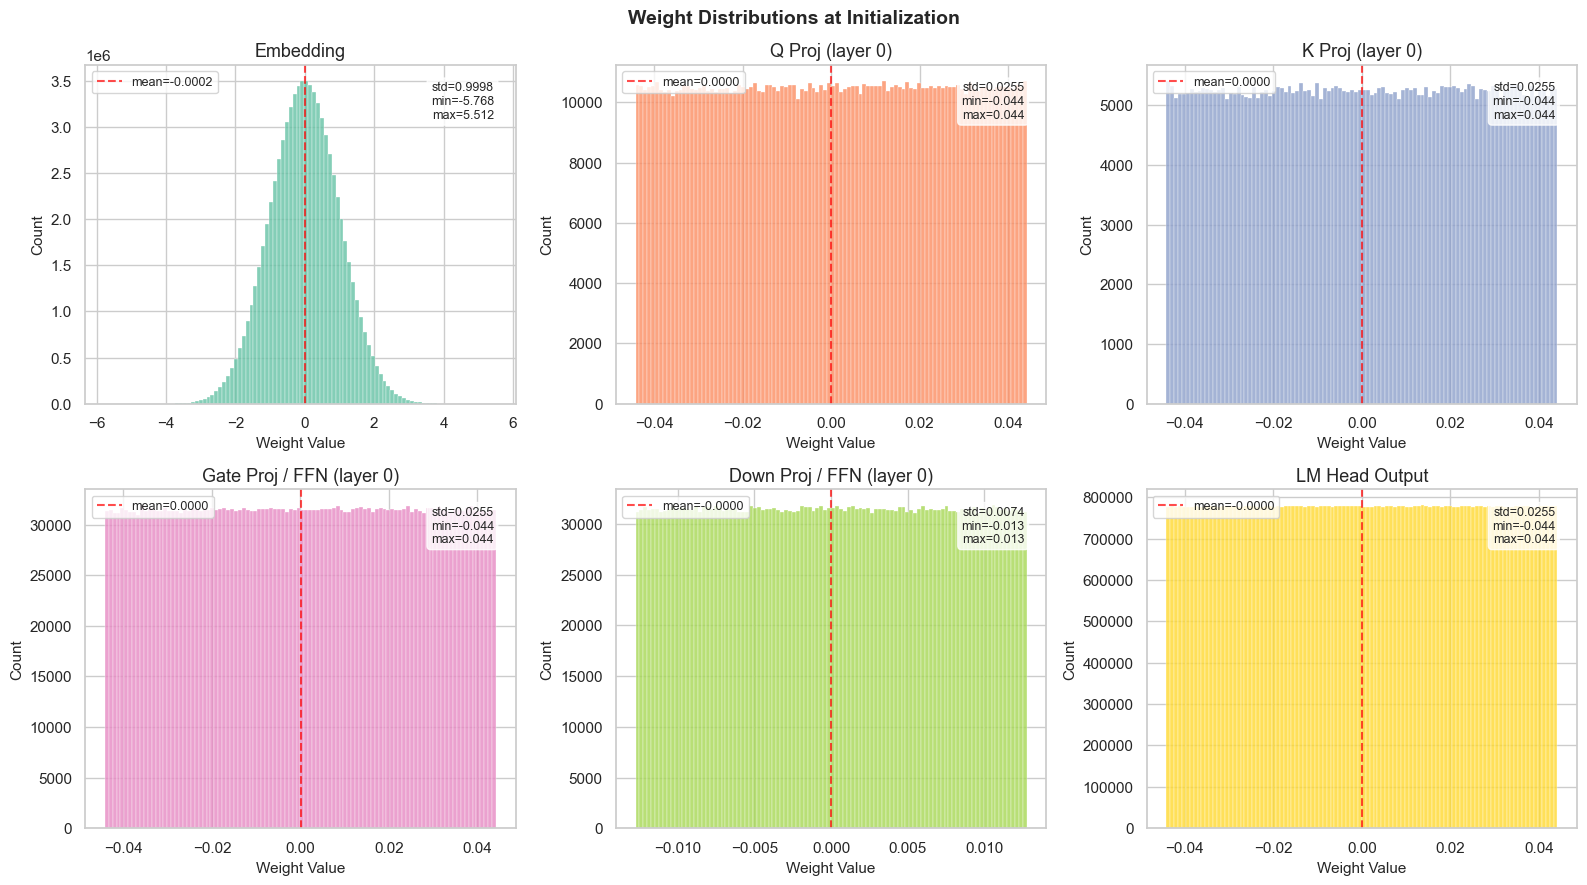

In [5]:
def plot_weight_distributions(model, title_prefix=''):
    """Plot weight histograms for major component types."""
    weight_groups = OrderedDict({
        'Embedding': [],
        'Q Proj (layer 0)': [],
        'K Proj (layer 0)': [],
        'Gate Proj / FFN (layer 0)': [],
        'Down Proj / FFN (layer 0)': [],
        'LM Head Output': [],
    })

    for name, param in model.named_parameters():
        data = param.detach().cpu().flatten().numpy()
        if 'embedding_layer' in name:
            weight_groups['Embedding'].append(data)
        elif 'attns.0.q_proj' in name:
            weight_groups['Q Proj (layer 0)'].append(data)
        elif 'attns.0.k_proj' in name:
            weight_groups['K Proj (layer 0)'].append(data)
        elif 'ffns.0' in name and 'gate_proj' in name:
            weight_groups['Gate Proj / FFN (layer 0)'].append(data)
        elif 'ffns.0' in name and 'down_proj' in name:
            weight_groups['Down Proj / FFN (layer 0)'].append(data)
        elif 'lm_head.out_layer' in name:
            weight_groups['LM Head Output'].append(data)

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    for idx, (name, weight_list) in enumerate(weight_groups.items()):
        if weight_list:
            all_weights = np.concatenate(weight_list)
            ax = axes[idx]
            ax.hist(all_weights, bins=100, color=COLORS[idx], alpha=0.8,
                    edgecolor='white', linewidth=0.3)
            ax.set_title(f'{title_prefix}{name}')
            ax.set_xlabel('Weight Value')
            ax.set_ylabel('Count')

            mean, std = all_weights.mean(), all_weights.std()
            ax.axvline(mean, color='red', linestyle='--', alpha=0.7, label=f'mean={mean:.4f}')
            ax.legend(fontsize=9)
            ax.text(0.95, 0.95,
                    f'std={std:.4f}\nmin={all_weights.min():.3f}\nmax={all_weights.max():.3f}',
                    transform=ax.transAxes, ha='right', va='top', fontsize=9,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.suptitle(f'{title_prefix}Weight Distributions at Initialization',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_weight_distributions(model)

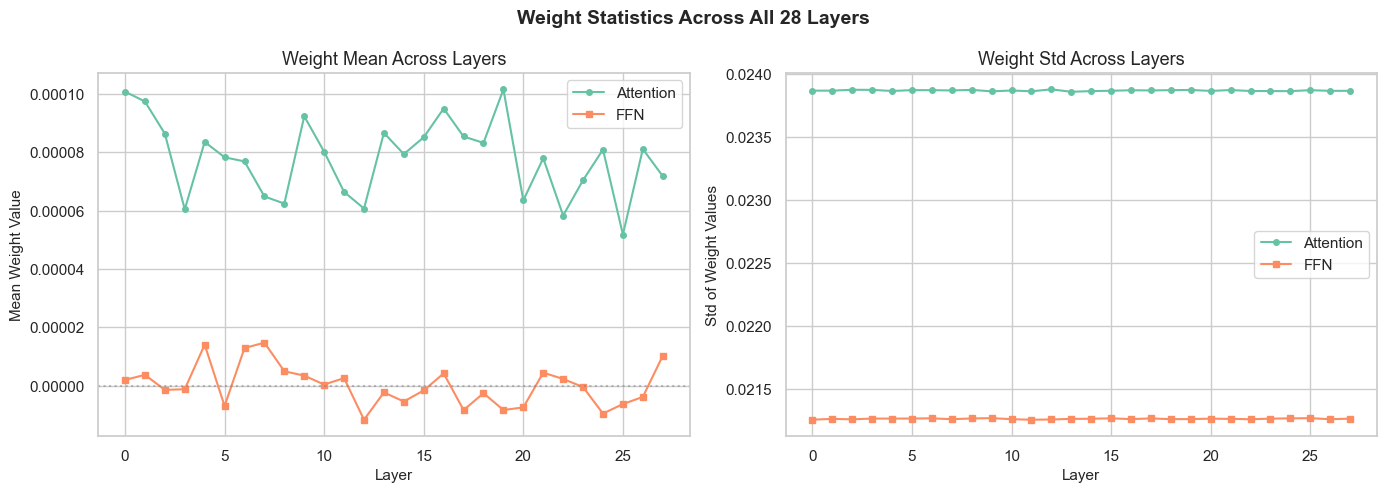

Right now these are flat — all layers initialized the same way.
After training, each layer develops its own distribution. That's learning.


In [6]:
def plot_weight_stats_across_layers(model, config):
    """Weight mean and std for attention and FFN across all 28 layers."""
    layers = range(config.n_layer)
    attn_means, attn_stds = [], []
    ffn_means, ffn_stds = [], []

    for i in layers:
        attn_params = []
        ffn_params = []
        for name, param in model.named_parameters():
            if f'attns.{i}.' in name:
                attn_params.append(param.detach().cpu().flatten())
            elif f'ffns.{i}.' in name:
                ffn_params.append(param.detach().cpu().flatten())
        if attn_params:
            all_attn = torch.cat(attn_params)
            attn_means.append(all_attn.mean().item())
            attn_stds.append(all_attn.std().item())
        if ffn_params:
            all_ffn = torch.cat(ffn_params)
            ffn_means.append(all_ffn.mean().item())
            ffn_stds.append(all_ffn.std().item())

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    x = list(layers)
    ax1.plot(x, attn_means, 'o-', color=COLORS[0], label='Attention', markersize=4)
    ax1.plot(x, ffn_means, 's-', color=COLORS[1], label='FFN', markersize=4)
    ax1.set_xlabel('Layer')
    ax1.set_ylabel('Mean Weight Value')
    ax1.set_title('Weight Mean Across Layers')
    ax1.legend()
    ax1.axhline(0, color='gray', linestyle=':', alpha=0.5)

    ax2.plot(x, attn_stds, 'o-', color=COLORS[0], label='Attention', markersize=4)
    ax2.plot(x, ffn_stds, 's-', color=COLORS[1], label='FFN', markersize=4)
    ax2.set_xlabel('Layer')
    ax2.set_ylabel('Std of Weight Values')
    ax2.set_title('Weight Std Across Layers')
    ax2.legend()

    plt.suptitle('Weight Statistics Across All 28 Layers', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('Right now these are flat — all layers initialized the same way.')
    print('After training, each layer develops its own distribution. That\'s learning.')


plot_weight_stats_across_layers(model, config)

---
## Part 3: What Does Untrained Attention See?

Attention is the core mechanism — it decides *which tokens should pay attention to which other tokens*.

With **random weights**, attention patterns are essentially **noise**.
Each head attends roughly equally to all previous tokens. There's no "understanding" yet.

After training, you'll see structured patterns:
- Some heads attend to the **previous token** (local patterns)
- Some heads attend to **semantically related tokens** (meaning)
- Some heads attend to **punctuation or special tokens** (structure)

In [7]:
# Tokenize a sample input
tok = ModelTokenizer(config)
sample_text = 'Why is math so important?'
input_ids = tok(sample_text)

token_labels = tok.tokenizer.convert_ids_to_tokens(input_ids[0].cpu().tolist())
print(f'Input: \'{sample_text}\'')
print(f'Tokens ({len(token_labels)}): {token_labels}')

# Forward pass — store_attn=True saves attention weights for visualization
with torch.no_grad():
    _ = model(input_ids, store_attn=True)

# Collect stored attention from all layers
all_attn = []
for i in range(config.n_layer):
    attn_layer = model.model_transformer.attns[i]
    if attn_layer._attn_weights is not None:
        all_attn.append(attn_layer._attn_weights)  # (1, num_heads, seq, seq)

print(f'Captured attention from {len(all_attn)} layers')
print(f'Shape per layer: {all_attn[0].shape}  (batch, heads, seq, seq)')

Input: 'Why is math so important?'
Tokens (6): ['Why', 'Ġis', 'Ġmath', 'Ġso', 'Ġimportant', '?']
Captured attention from 28 layers
Shape per layer: torch.Size([1, 16, 6, 6])  (batch, heads, seq, seq)


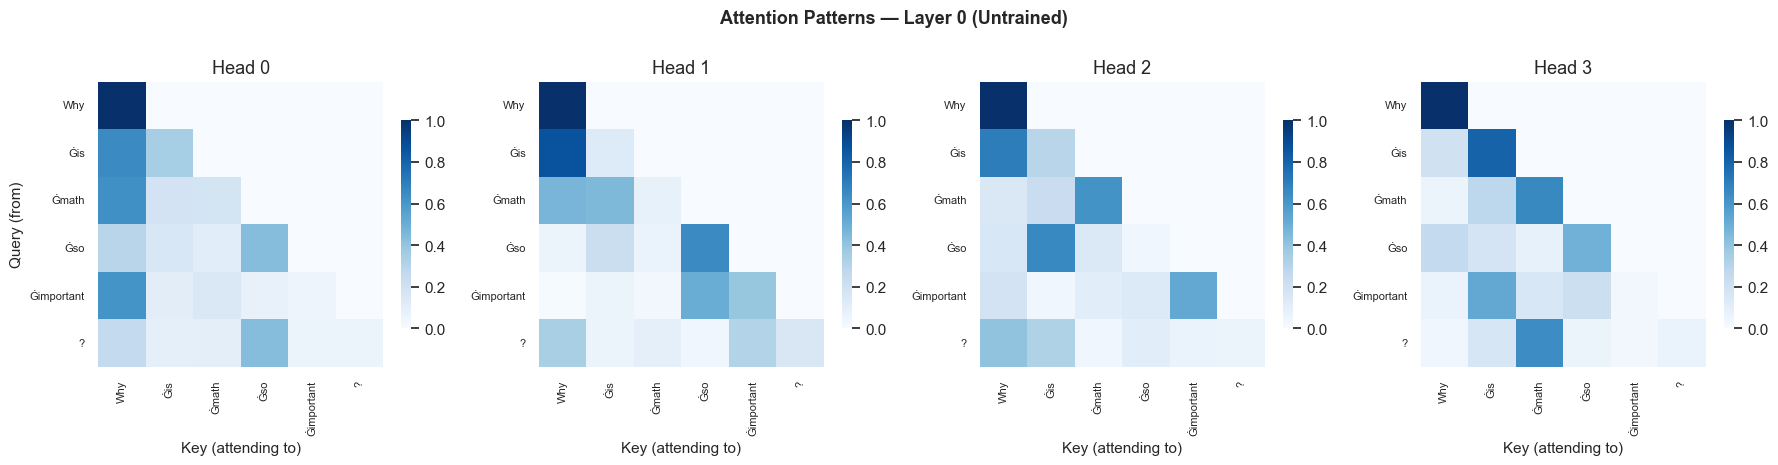

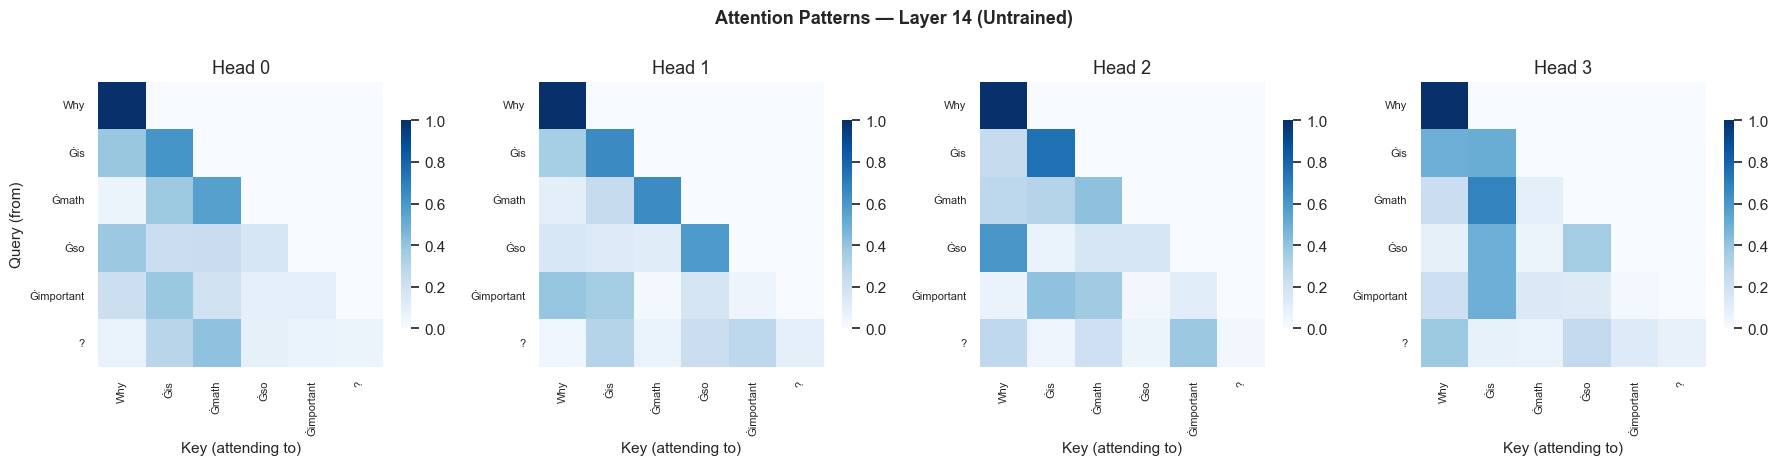

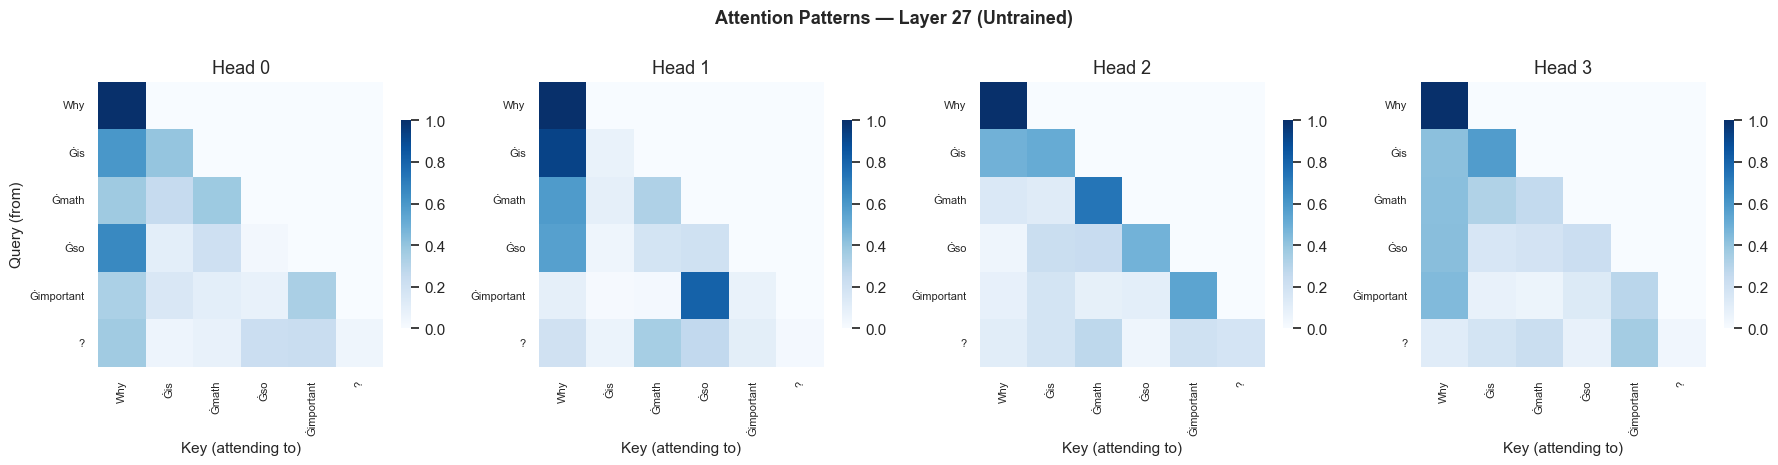

In [8]:
def plot_attention_heads(attn_weights, layer_idx, token_labels, heads_to_show=4):
    """Plot attention heatmaps for specific heads in a layer."""
    attn = attn_weights[layer_idx][0]  # remove batch dim -> (num_heads, seq, seq)
    n_heads = min(heads_to_show, attn.shape[0])

    fig, axes = plt.subplots(1, n_heads, figsize=(4.5 * n_heads, 4.5))
    if n_heads == 1:
        axes = [axes]

    short_labels = [t[:10] for t in token_labels]

    for i in range(n_heads):
        sns.heatmap(
            attn[i].numpy(), ax=axes[i], cmap='Blues',
            vmin=0, vmax=attn[i].max().item(),
            xticklabels=short_labels, yticklabels=short_labels,
            square=True, cbar_kws={'shrink': 0.6}
        )
        axes[i].set_title(f'Head {i}')
        axes[i].set_xlabel('Key (attending to)')
        if i == 0:
            axes[i].set_ylabel('Query (from)')
        axes[i].tick_params(axis='both', labelsize=8)

    plt.suptitle(f'Attention Patterns — Layer {layer_idx} (Untrained)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Show first layer, middle layer, last layer
for layer_idx in [0, config.n_layer // 2, config.n_layer - 1]:
    plot_attention_heads(all_attn, layer_idx, token_labels, heads_to_show=4)

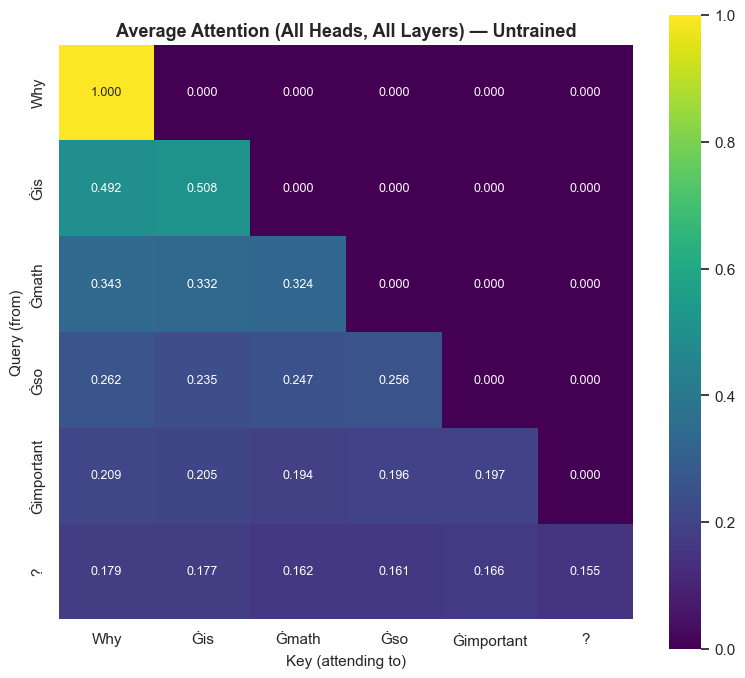

With random weights, attention is roughly uniform across allowed positions.
The causal mask is visible — tokens can only attend to earlier tokens (+ themselves).
After training, you'd see diagonal patterns and semantic attention emerge.


In [9]:
def plot_average_attention(attn_weights, token_labels):
    """Average attention across all heads and layers."""
    stacked = torch.stack(attn_weights)  # (n_layers, 1, heads, seq, seq)
    avg_attn = stacked.mean(dim=(0, 1, 2)).numpy()  # (seq, seq)

    fig, ax = plt.subplots(figsize=(8, 7))
    short_labels = [t[:10] for t in token_labels]

    sns.heatmap(
        avg_attn, ax=ax, cmap='viridis',
        xticklabels=short_labels, yticklabels=short_labels,
        square=True, annot=True, fmt='.3f', annot_kws={'size': 9}
    )
    ax.set_title('Average Attention (All Heads, All Layers) — Untrained',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Key (attending to)')
    ax.set_ylabel('Query (from)')
    plt.tight_layout()
    plt.show()

    print('With random weights, attention is roughly uniform across allowed positions.')
    print('The causal mask is visible — tokens can only attend to earlier tokens (+ themselves).')
    print('After training, you\'d see diagonal patterns and semantic attention emerge.')


plot_average_attention(all_attn, token_labels)

---
## Part 4: Signal Flow Through the Network

Your model has **28 transformer layers**. Information flows through all of them.
A critical question: **does the signal survive?**

- If activations shrink toward zero through layers -> **vanishing signal** (bad)
- If activations grow through layers -> **exploding signal** (bad)
- If they stay roughly stable -> **healthy flow** (good)

The residual connections (`x = attention(norm(x)) + x`) are designed to prevent this.
Let's check if they work.

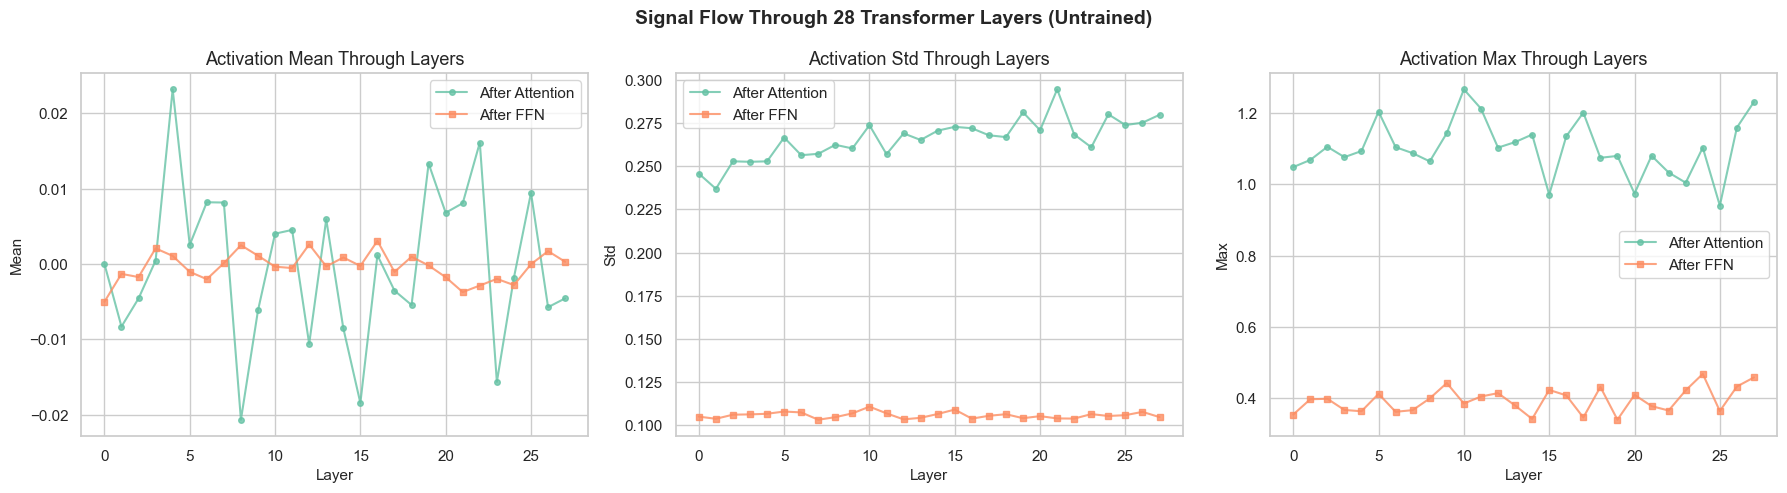

Embedding output  -> mean: 0.0544, std: 0.9830
Final layer (27)  -> mean: 0.0003, std: 0.1045

Signal ratio (final/embedding std): 0.11 -- looks healthy.


In [10]:
def analyze_activation_flow(model, input_ids, config):
    """Hook into each layer and record activation statistics."""
    stats = {'layer': [], 'position': [], 'mean': [], 'std': [], 'max': []}
    hooks = []

    def make_hook(layer_idx, position):
        def hook_fn(module, input, output):
            if isinstance(output, torch.Tensor):
                data = output.detach().float()
            else:
                data = input[0].detach().float()
            stats['layer'].append(layer_idx)
            stats['position'].append(position)
            stats['mean'].append(data.mean().item())
            stats['std'].append(data.std().item())
            stats['max'].append(data.abs().max().item())
        return hook_fn

    # Register hooks on attention and FFN outputs
    hooks.append(model.embedding_layer.register_forward_hook(make_hook(-1, 'embedding')))
    for i in range(config.n_layer):
        hooks.append(model.model_transformer.attns[i].register_forward_hook(
            make_hook(i, 'post_attn')))
        hooks.append(model.model_transformer.ffns[i].register_forward_hook(
            make_hook(i, 'post_ffn')))

    with torch.no_grad():
        _ = model(input_ids)

    for h in hooks:
        h.remove()

    return pd.DataFrame(stats)


flow_df = analyze_activation_flow(model, input_ids, config)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, metric in enumerate(['mean', 'std', 'max']):
    ax = axes[idx]
    post_attn = flow_df[flow_df['position'] == 'post_attn']
    post_ffn = flow_df[flow_df['position'] == 'post_ffn']

    ax.plot(post_attn['layer'], post_attn[metric], 'o-', color=COLORS[0],
            label='After Attention', markersize=4, alpha=0.8)
    ax.plot(post_ffn['layer'], post_ffn[metric], 's-', color=COLORS[1],
            label='After FFN', markersize=4, alpha=0.8)
    ax.set_xlabel('Layer')
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f'Activation {metric.capitalize()} Through Layers')
    ax.legend()

plt.suptitle('Signal Flow Through 28 Transformer Layers (Untrained)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

emb_row = flow_df[flow_df['position'] == 'embedding'].iloc[0]
final_row = post_ffn.iloc[-1]
print(f'Embedding output  -> mean: {emb_row["mean"]:.4f}, std: {emb_row["std"]:.4f}')
print(f'Final layer (27)  -> mean: {final_row["mean"]:.4f}, std: {final_row["std"]:.4f}')
print()
ratio = final_row['std'] / emb_row['std']
if 0.1 < ratio < 10:
    print(f'Signal ratio (final/embedding std): {ratio:.2f} -- looks healthy.')
elif ratio > 10:
    print(f'Signal ratio: {ratio:.2f} -- signal is growing (possible exploding activations).')
else:
    print(f'Signal ratio: {ratio:.2f} -- signal is shrinking (possible vanishing activations).')

---
## Part 5: Snapshot & Comparison Framework

These utilities let you **save the current state** of your model and **compare** it to a
future version (after training, or against the real Qwen3 weights).

### How to use:
1. Run `save_snapshot(model, 'untrained')` now (done below)
2. Train your model later
3. Run `save_snapshot(model, 'trained')`
4. Run `compare_snapshots('untrained', 'trained')` to see what changed

In [11]:
import os

SNAPSHOT_DIR = '../snapshots'
os.makedirs(SNAPSHOT_DIR, exist_ok=True)


def save_snapshot(model, name: str):
    """Save model weight statistics for later comparison."""
    snapshot = {}
    for param_name, param in model.named_parameters():
        data = param.detach().cpu().float()
        snapshot[param_name] = {
            'mean': data.mean().item(),
            'std': data.std().item(),
            'min': data.min().item(),
            'max': data.max().item(),
            'shape': list(data.shape),
            'histogram': np.histogram(data.numpy().flatten(), bins=50),
        }

    path = os.path.join(SNAPSHOT_DIR, f'{name}.pt')
    torch.save(snapshot, path)
    print(f'Saved snapshot \'{name}\' -> {path} ({len(snapshot)} parameters)')
    return snapshot


def load_snapshot(name: str):
    path = os.path.join(SNAPSHOT_DIR, f'{name}.pt')
    return torch.load(path, weights_only=False)


def compare_snapshots(name_a: str, name_b: str):
    """Visual comparison of two model snapshots."""
    snap_a = load_snapshot(name_a)
    snap_b = load_snapshot(name_b)

    params = list(snap_a.keys())
    stds_a = [snap_a[p]['std'] for p in params]
    stds_b = [snap_b[p]['std'] for p in params]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Std comparison scatter
    ax = axes[0]
    x = range(len(params))
    ax.scatter(x, stds_a, alpha=0.5, s=10, label=name_a, color=COLORS[0])
    ax.scatter(x, stds_b, alpha=0.5, s=10, label=name_b, color=COLORS[1])
    ax.set_xlabel('Parameter Index')
    ax.set_ylabel('Weight Std')
    ax.set_title('Weight Standard Deviation: Before vs After')
    ax.legend()

    # Delta histogram
    ax = axes[1]
    deltas = [stds_b[i] - stds_a[i] for i in range(len(params))]
    ax.hist(deltas, bins=50, color=COLORS[2], alpha=0.8, edgecolor='white')
    ax.set_xlabel('Change in Std (after - before)')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Weight Changes')
    ax.axvline(0, color='red', linestyle='--', alpha=0.7)

    plt.suptitle(f'Comparison: "{name_a}" vs "{name_b}"',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Save the untrained snapshot now
untrained_snap = save_snapshot(model, 'untrained')
print()
print('Snapshot saved. After training, run:')
print('  save_snapshot(model, \'trained\')')
print('  compare_snapshots(\'untrained\', \'trained\')')

Saved snapshot 'untrained' -> ../snapshots/untrained.pt (311 parameters)

Snapshot saved. After training, run:
  save_snapshot(model, 'trained')
  compare_snapshots('untrained', 'trained')


---
## What I Learned

### Key Takeaways

**1. Parameter allocation is uneven**
- The FFN layers (SwiGLU) hold the most parameters — roughly 3x more than attention
- The embedding and LM head are huge because vocab_size (151,936) is massive
- RMSNorm barely registers — it's just one learned vector per normalization

**2. Random initialization has structure, it's not pure chaos**
- Kaiming uniform produces distributions scaled to layer size
- Smaller layers -> wider distributions, larger layers -> tighter distributions
- This scaling prevents signals from exploding or vanishing at the start

**3. Untrained attention is near-uniform**
- Without training, every token attends roughly equally to all previous tokens
- The only structure comes from the causal mask (can't look at future tokens)
- Training is what creates meaningful attention patterns

**4. Signal flow depends on architecture choices**
- Residual connections keep activations from vanishing through 28 layers
- Pre-norm (normalize before attention/FFN) helps stabilize training
- Without these, deep transformers would be untrainable

### Next Steps
- [ ] Train the model (even a little) and re-run this notebook to compare
- [ ] Use `compare_snapshots('untrained', 'trained')` to see what changed
- [ ] Load real Qwen3-1.7B weights and compare attention patterns
- [ ] Investigate which attention heads specialize after training